# 03 多尺度收益

本 Notebook 从正式 silver 独立重算固定三个月交割合约链，基于真实日盘一分钟事实构造 5、15、30、60 分钟与日收益，并复现论文 Table 3 的描述统计方法和 Figure 1 的 30 分钟收益时序图。

本项不依赖前两本 Notebook 的输出，不调用 API，不读取或写入项目缓存，不写 silver 或 gold。AL、CU、FU 是论文品种；RB 始终单独标记为论文外扩展。FU 旧产品段与稳定重启段作为两个独立序列。

## 1. 在做什么，以及经济意义

收益采样频率决定“信息量”和“微观结构噪声”之间的取舍。高频收益保留更多日内变化，却更容易出现大量零收益和尖峰厚尾；频率降低后，零收益通常减少，但样本数量和日内细节也随之下降。

本项回答：

1. 固定三个月合约在五种频率下的均值、波动、偏度、超额峰度和极值如何变化？
2. 零收益比例是否随频率降低而下降？
3. 30 分钟收益时序中，波动聚集和极端波动出现在哪些时期？
4. 当前湖仓样本与论文原 GTA 样本在方向上是否一致，而不把数值差异误写成失败？

## 2. 论文对应、收益定义与当前复现等级

论文公式 (10) 定义五分钟对数收益为 `r[t,n] = log(P[t,n]) - log(P[t,n-1])`；15、30、60 分钟与日收益由更长间隔的对数价格差得到。Table 3 报告 Mean、Stdev、Skew、Kurt、Min、Max、Count 和 Zero return (%)；正文将 Kurt 解释为超额峰度。Figure 1 展示完整样本的 30 分钟收益序列。

项目冻结实现：

- 每个真实 Session 的首分钟以该 Session 的 `open` 为参考；其余分钟以前一分钟 `close` 为参考。夜盘、隔夜、晨休与午休跳空都不进入收益。
- 将这些 Session 内一分钟收益按当日真实交易分钟顺序连接，再按全日交易分钟序号聚合。5、15 分钟各为 45、15 个完整槽位；30 分钟为 7 个完整槽位加 1 个 15 分钟末槽；60 分钟为 3 个完整槽位加 1 个 45 分钟末槽。
- 30、60 分钟槽位可以包含休市前后两个 Session 的收益片段，但只相加各 Session 内已经锚定的收益，不计入休市价差。
- 日收益是同一日 225 个 Session 内分钟收益之和，不使用昨日收盘价，因此不是含隔夜信息的 close-to-close 收益。
- 数值零收益使用 `abs(return) <= 1e-12` 判定，只吸收对数望远镜求和的浮点误差；最小有效价格跳动远大于该阈值。
- Stdev 使用样本标准差；Skew 和 Kurt 使用无偏样本统计，Kurt 为 Fisher 超额峰度。

**复现等级：论文方法框架复现。** 论文原交易时段每天形成 48 个五分钟收益；本项目严格使用正式湖中 225 个真实日盘分钟，形成 45 个五分钟收益，不补造晨休分钟。

In [1]:
from __future__ import annotations

from datetime import date
import gc
import pathlib
import sys
import time

project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()

for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        sys.path.insert(0, str(candidate_root / "02_Futures_Lakehouse"))
        project_root = candidate_root
        break
else:
    raise RuntimeError("未找到项目根目录")

expected_python = pathlib.Path(r"E:\anaconda3\envs\latitude_env_v2\python.exe").resolve()
current_python = pathlib.Path(sys.executable).resolve()
assert current_python == expected_python, (
    f"必须使用 latitude_env_v2 环境解释器 {expected_python}，实际为 {current_python}"
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
from IPython.display import Markdown, display
from scipy.stats import kurtosis, skew

from config.data_contracts import (
    FUTURES_BAR_CALENDAR_SCHEMA,
    FUTURES_CONTRACT_CALENDAR_SCHEMA,
    FUTURES_MINUTE_SCHEMA,
    FUTURES_VARIETY_CALENDAR_SCHEMA,
    arrow_to_pandas,
    validate_arrow_table,
)
from a00_03_notebook_schema_browser import display_schema_metadata
from config.settings import settings

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 200)

print(f"Python: {sys.executable}")
print(f"项目根目录: {project_root}")
print(f"正式湖仓根目录: {settings.futures_lake_root}")

Python: E:\anaconda3\envs\latitude\python.exe
项目根目录: E:\Latitude_Analytics_v2
正式湖仓根目录: E:\Latitude_Analytics_v2\03_Futures_Database\futures_lake


## 3. 开篇 Schema metadata 浏览器

本项直接参与的权威表依次为品种交易日、合约 Session 日历、一分钟抓取/质量日历和一分钟事实。日收益由日盘分钟收益构造，不读取可能包含不同休市跳空口径的日频事实。

In [2]:
display_schema_metadata(
    [
        FUTURES_VARIETY_CALENDAR_SCHEMA,
        FUTURES_CONTRACT_CALENDAR_SCHEMA,
        FUTURES_BAR_CALENDAR_SCHEMA,
        FUTURES_MINUTE_SCHEMA,
    ]
)

英文表名,中文表名,字段数,主键,Hive 分区,Schema 版本
dim_futures_variety_calendar,期货品种交易日历维度表,8,"exchange_code,underlying_code,trading_date","exchange_code,year,month",1.2.0
dim_futures_contract_calendar,期货合约 Session 日历维度表,21,"contract_code,trading_date,session_number","exchange_code,year,month",1.2.0
dim_futures_bar_calendar,期货行情拉取与质检日历维度表,48,"bar_frequency,contract_code,trading_date,session_number","bar_frequency,exchange_code,year,month",1.4.0
fact_futures_minute,国内期货合约一分钟行情事实表,17,"contract_code,bar_at","exchange_code,underlying_code,year,month",1.5.0


## 4. 参数、固定样本与代码步骤

线性代码分为八步：

1. 从 Schema metadata 打开四张正式表并检查物理兼容性；
2. 从品种交易日表冻结五个研究序列与样本端点；
3. 解析交割年月，逐交易日选择“交易月后第 3 个月交割”的唯一固定月份合约并标记换月；
4. 用 bar calendar 的正式完成证据筛选三个完整日盘 Session；
5. 按“研究序列 × 年”过滤读取分钟事实，以精确 Session 键排除夜盘；
6. Session 内构造一分钟收益，再按全日交易分钟序号聚合五种频率；
7. 生成 Table 3 风格统计和 Figure 1 风格 30 分钟时序图；
8. 独立验证样本、合约、Session、槽位、跨频率加总、有限性和零收益边界。

In [3]:
exchange_code = "XSGE"
sample_start = date(2010, 1, 4)
sample_end = date(2026, 8, 28)
zero_return_tolerance = 1e-12

sample_spec_df = pd.DataFrame(
    [
        ("AL", "AL", date(2010, 1, 4), date(2026, 8, 28), "论文品种"),
        ("CU", "CU", date(2010, 1, 4), date(2026, 8, 28), "论文品种"),
        ("FU_legacy", "FU", date(2010, 1, 4), date(2011, 9, 30), "论文品种：旧产品段"),
        ("FU_relaunched", "FU", date(2020, 1, 2), date(2026, 8, 28), "论文品种：稳定重启段"),
        ("RB", "RB", date(2010, 1, 4), date(2026, 8, 28), "论文外扩展品种"),
    ],
    columns=[
        "series_id",
        "underlying_code",
        "sample_start",
        "sample_end",
        "research_role",
    ],
)
sample_spec_df["sample_start"] = pd.to_datetime(sample_spec_df["sample_start"])
sample_spec_df["sample_end"] = pd.to_datetime(sample_spec_df["sample_end"])
series_order = sample_spec_df["series_id"].tolist()

interval_spec_df = pd.DataFrame(
    [
        ("5-min", 5, 45, 5),
        ("15-min", 15, 15, 15),
        ("30-min", 30, 8, 15),
        ("60-min", 60, 4, 45),
        ("Daily", 225, 1, 225),
    ],
    columns=[
        "interval_label",
        "target_interval_minutes",
        "expected_daily_slots",
        "expected_last_slot_minutes",
    ],
)
interval_order = interval_spec_df["interval_label"].tolist()
display(sample_spec_df)
display(interval_spec_df)

,series_id,underlying_code,sample_start,sample_end,research_role
0,AL,AL,2010-01-04,2026-08-28,论文品种
1,CU,CU,2010-01-04,2026-08-28,论文品种
2,FU_legacy,FU,2010-01-04,2011-09-30,论文品种：旧产品段
3,FU_relaunched,FU,2020-01-02,2026-08-28,论文品种：稳定重启段
4,RB,RB,2010-01-04,2026-08-28,论文外扩展品种


,interval_label,target_interval_minutes,expected_daily_slots,expected_last_slot_minutes
0,5-min,5,45,5
1,15-min,15,15,15
2,30-min,30,8,15
3,60-min,60,4,45
4,Daily,225,1,225


## 5. 直接 PyArrow 过滤读取与转换

表名、主键、分区列来自 Schema metadata；字段类型和 nullable 来自权威 `pa.Schema`。每次只读取本项所需列，并在 Arrow 层先过滤交易所、品种、年份和日期。

In [4]:
source_schema_by_role = {
    "variety_calendar": FUTURES_VARIETY_CALENDAR_SCHEMA,
    "contract_calendar": FUTURES_CONTRACT_CALENDAR_SCHEMA,
    "bar_calendar": FUTURES_BAR_CALENDAR_SCHEMA,
    "minute_fact": FUTURES_MINUTE_SCHEMA,
}
source_dataset_by_role = {}
source_contract_audit_rows = []

for source_role, source_schema in source_schema_by_role.items():
    source_metadata = {
        key.decode("utf-8"): value.decode("utf-8")
        for key, value in source_schema.metadata.items()
    }
    table_name = source_metadata["table_name"]
    primary_key = source_metadata["primary_key"].split(",")
    partition_columns = source_metadata["partition_columns"].split(",")
    table_path = settings.futures_lake_root / "silver" / table_name
    partitioning = ds.partitioning(
        pa.schema(
            [source_schema.field(column_name) for column_name in partition_columns]
        ),
        flavor="hive",
    )
    source_dataset = ds.dataset(
        table_path,
        format="parquet",
        partitioning=partitioning,
    )

    physical_mismatches = []
    for expected_field in source_schema:
        actual_field = source_dataset.schema.field(expected_field.name)
        if (
            actual_field.type != expected_field.type
            or actual_field.nullable != expected_field.nullable
        ):
            physical_mismatches.append(
                {
                    "field": expected_field.name,
                    "expected_type": str(expected_field.type),
                    "actual_type": str(actual_field.type),
                    "expected_nullable": expected_field.nullable,
                    "actual_nullable": actual_field.nullable,
                }
            )
    if physical_mismatches:
        raise TypeError({table_name: physical_mismatches})

    source_dataset_by_role[source_role] = source_dataset
    source_contract_audit_rows.append(
        {
            "source_role": source_role,
            "table_name": table_name,
            "primary_key": ",".join(primary_key),
            "partition_columns": ",".join(partition_columns),
            "physical_mismatch_count": len(physical_mismatches),
        }
    )

source_contract_audit_df = pd.DataFrame(source_contract_audit_rows)
display(source_contract_audit_df)

,source_role,table_name,primary_key,partition_columns,physical_mismatch_count
0,variety_calendar,dim_futures_variety_calendar,"exchange_code,underlying_code,trading_date","exchange_code,year,month",0
1,contract_calendar,dim_futures_contract_calendar,"contract_code,trading_date,session_number","exchange_code,year,month",0
2,bar_calendar,dim_futures_bar_calendar,"bar_frequency,contract_code,trading_date,session_number","bar_frequency,exchange_code,year,month",0
3,minute_fact,fact_futures_minute,"contract_code,bar_at","exchange_code,underlying_code,year,month",0


In [5]:
trading_date_field = ds.field("trading_date")
underlying_field = ds.field("underlying_code")
base_filter = (
    (ds.field("exchange_code") == exchange_code)
    & (ds.field("year") >= sample_start.year)
    & (ds.field("year") <= sample_end.year)
)
main_series_filter = (
    underlying_field.isin(["AL", "CU", "RB"])
    & (trading_date_field >= pa.scalar(sample_start, type=pa.date32()))
    & (trading_date_field <= pa.scalar(sample_end, type=pa.date32()))
)
fu_series_filter = (
    (underlying_field == "FU")
    & (
        (
            (trading_date_field >= pa.scalar(date(2010, 1, 4), type=pa.date32()))
            & (trading_date_field <= pa.scalar(date(2011, 9, 30), type=pa.date32()))
        )
        | (
            (trading_date_field >= pa.scalar(date(2020, 1, 2), type=pa.date32()))
            & (trading_date_field <= pa.scalar(date(2026, 8, 28), type=pa.date32()))
        )
    )
)
research_sample_filter = base_filter & (main_series_filter | fu_series_filter)

variety_columns = [
    "underlying_code",
    "exchange_code",
    "trading_date",
    "active_contract_count",
]
variety_projection_schema = pa.schema(
    [
        FUTURES_VARIETY_CALENDAR_SCHEMA.field(column_name)
        for column_name in variety_columns
    ]
)
variety_calendar_table = source_dataset_by_role["variety_calendar"].to_table(
    columns=variety_columns,
    filter=research_sample_filter,
)
validated_variety_calendar_table = validate_arrow_table(
    variety_calendar_table,
    variety_projection_schema,
)
variety_calendar_df = arrow_to_pandas(
    validated_variety_calendar_table,
    variety_projection_schema,
)
variety_calendar_df["trading_date"] = pd.to_datetime(
    variety_calendar_df["trading_date"]
)

expected_sample_pieces = []
for sample_spec in sample_spec_df.itertuples(index=False):
    expected_series_df = variety_calendar_df.loc[
        (variety_calendar_df["underlying_code"] == sample_spec.underlying_code)
        & (variety_calendar_df["trading_date"] >= sample_spec.sample_start)
        & (variety_calendar_df["trading_date"] <= sample_spec.sample_end)
    ].copy()
    expected_series_df.insert(0, "series_id", sample_spec.series_id)
    expected_sample_pieces.append(expected_series_df)

expected_sample_df = pd.concat(
    expected_sample_pieces,
    ignore_index=True,
).sort_values(["series_id", "trading_date"], ignore_index=True)

target_delivery_period = (
    pd.PeriodIndex(expected_sample_df["trading_date"], freq="M") + 3
)
expected_sample_df["target_delivery_year"] = target_delivery_period.year
expected_sample_df["target_delivery_month"] = target_delivery_period.month
expected_sample_df["expected_contract_code"] = (
    expected_sample_df["underlying_code"].astype("string")
    + expected_sample_df["target_delivery_year"].mod(100).astype("string").str.zfill(2)
    + expected_sample_df["target_delivery_month"].astype("string").str.zfill(2)
    + "."
    + expected_sample_df["exchange_code"].astype("string")
)

display(
    expected_sample_df.groupby("series_id", observed=True)["trading_date"]
    .agg(
        expected_trading_days="size",
        first_date="min",
        last_date="max",
    )
    .reset_index()
)

,series_id,expected_trading_days,first_date,last_date
0,AL,4045,2010-01-04,2026-08-28
1,CU,4045,2010-01-04,2026-08-28
2,FU_legacy,426,2010-01-04,2011-09-30
3,FU_relaunched,1614,2020-01-02,2026-08-28
4,RB,4045,2010-01-04,2026-08-28


In [6]:
contract_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "session_start_at",
    "session_end_at",
    "is_night_session",
    "minute_count",
]
contract_projection_schema = pa.schema(
    [
        FUTURES_CONTRACT_CALENDAR_SCHEMA.field(column_name)
        for column_name in contract_columns
    ]
)
day_contract_filter = research_sample_filter & (
    ds.field("is_night_session") == False
)
contract_calendar_table = source_dataset_by_role["contract_calendar"].to_table(
    columns=contract_columns,
    filter=day_contract_filter,
)
validated_contract_calendar_table = validate_arrow_table(
    contract_calendar_table,
    contract_projection_schema,
)
contract_calendar_df = arrow_to_pandas(
    validated_contract_calendar_table,
    contract_projection_schema,
)
contract_calendar_df["trading_date"] = pd.to_datetime(
    contract_calendar_df["trading_date"]
)

contract_code_parts = contract_calendar_df["contract_code"].astype("string").str.extract(
    r"^([A-Z]+)(\d{4})\.([A-Z]+)$"
)
if not contract_code_parts.notna().all().all():
    invalid_contract_codes = contract_calendar_df.loc[
        contract_code_parts.isna().any(axis=1),
        "contract_code",
    ].drop_duplicates()
    raise ValueError(
        f"发现无法解析的固定月份合约代码: {invalid_contract_codes.tolist()}"
    )

contract_calendar_df["code_underlying"] = contract_code_parts[0]
contract_calendar_df["delivery_year"] = (
    2000 + contract_code_parts[1].str[:2].astype("int16")
)
contract_calendar_df["delivery_month"] = (
    contract_code_parts[1].str[2:].astype("int8")
)
contract_calendar_df["code_exchange"] = contract_code_parts[2]
trade_plus_three_period = (
    pd.PeriodIndex(contract_calendar_df["trading_date"], freq="M") + 3
)
contract_calendar_df["is_target_delivery"] = (
    contract_calendar_df["delivery_year"].eq(trade_plus_three_period.year)
    & contract_calendar_df["delivery_month"].eq(trade_plus_three_period.month)
)

assert (
    contract_calendar_df["code_underlying"]
    == contract_calendar_df["underlying_code"]
).all()
assert (
    contract_calendar_df["code_exchange"]
    == contract_calendar_df["exchange_code"]
).all()
assert not contract_calendar_df["is_night_session"].any()

target_session_df = contract_calendar_df.loc[
    contract_calendar_df["is_target_delivery"]
].copy()
target_contract_count_df = (
    target_session_df.groupby(
        ["underlying_code", "trading_date"],
        observed=True,
    )["contract_code"]
    .nunique()
    .rename("target_contract_count")
    .reset_index()
)
target_contract_day_df = (
    target_session_df.groupby(
        [
            "underlying_code",
            "trading_date",
            "contract_code",
            "delivery_year",
            "delivery_month",
        ],
        observed=True,
        sort=True,
    )
    .agg(
        day_session_count=("session_number", "nunique"),
        day_minute_count=("minute_count", "sum"),
    )
    .reset_index()
)

contract_mapping_audit_df = expected_sample_df.merge(
    target_contract_count_df,
    on=["underlying_code", "trading_date"],
    how="left",
    validate="one_to_one",
)
contract_mapping_audit_df["target_contract_count"] = (
    contract_mapping_audit_df["target_contract_count"]
    .fillna(0)
    .astype("int64")
)
assert contract_mapping_audit_df["target_contract_count"].le(1).all()

contract_mapping_audit_df = contract_mapping_audit_df.merge(
    target_contract_day_df,
    on=["underlying_code", "trading_date"],
    how="left",
    validate="one_to_one",
)
contract_mapping_audit_df["mapping_status"] = np.where(
    contract_mapping_audit_df["contract_code"].notna(),
    "selected",
    "excluded_target_contract_not_listed",
)
missing_contract_mapping_df = contract_mapping_audit_df.loc[
    contract_mapping_audit_df["mapping_status"] != "selected",
    [
        "series_id",
        "trading_date",
        "expected_contract_code",
        "target_contract_count",
        "mapping_status",
    ],
].copy()

known_missing_keys_df = expected_sample_df.loc[
    (expected_sample_df["series_id"] == "FU_legacy")
    & (
        expected_sample_df["trading_date"].dt.to_period("M")
        == pd.Period("2010-11")
    ),
    ["series_id", "trading_date", "expected_contract_code"],
].sort_values(["series_id", "trading_date"], ignore_index=True)
actual_missing_keys_df = missing_contract_mapping_df[
    ["series_id", "trading_date", "expected_contract_code"]
].sort_values(["series_id", "trading_date"], ignore_index=True)
assert actual_missing_keys_df.equals(known_missing_keys_df)
assert set(actual_missing_keys_df["expected_contract_code"]) == {
    "FU1102.XSGE"
}

contract_series_df = contract_mapping_audit_df.loc[
    contract_mapping_audit_df["mapping_status"] == "selected"
].copy()
contract_series_df = contract_series_df.sort_values(
    ["series_id", "trading_date"],
    ignore_index=True,
)
contract_series_df["previous_contract_code"] = (
    contract_series_df.groupby(
        "series_id",
        observed=True,
    )["contract_code"].shift()
)
contract_series_df["is_roll_day"] = (
    contract_series_df["previous_contract_code"].notna()
    & contract_series_df["contract_code"].ne(
        contract_series_df["previous_contract_code"]
    )
).astype("bool")

selected_target_session_df = target_session_df.merge(
    contract_series_df[
        [
            "series_id",
            "underlying_code",
            "trading_date",
            "contract_code",
            "delivery_year",
            "delivery_month",
            "is_roll_day",
        ]
    ],
    on=[
        "underlying_code",
        "trading_date",
        "contract_code",
        "delivery_year",
        "delivery_month",
    ],
    how="inner",
    validate="many_to_one",
)
assert selected_target_session_df.groupby(
    ["series_id", "trading_date"],
    observed=True,
)["session_number"].nunique().eq(3).all()

display(missing_contract_mapping_df)
display(
    contract_series_df.groupby("series_id", observed=True)
    .agg(
        selected_trading_days=("trading_date", "size"),
        first_selected_date=("trading_date", "min"),
        last_selected_date=("trading_date", "max"),
        unique_contracts=("contract_code", "nunique"),
        roll_days=("is_roll_day", "sum"),
    )
    .reset_index()
)

,series_id,trading_date,expected_contract_code,target_contract_count,mapping_status
8287,FU_legacy,2010-11-01,FU1102.XSGE,0,excluded_target_contract_not_listed
8288,FU_legacy,2010-11-02,FU1102.XSGE,0,excluded_target_contract_not_listed
8289,FU_legacy,2010-11-03,FU1102.XSGE,0,excluded_target_contract_not_listed
8290,FU_legacy,2010-11-04,FU1102.XSGE,0,excluded_target_contract_not_listed
8291,FU_legacy,2010-11-05,FU1102.XSGE,0,excluded_target_contract_not_listed
8292,FU_legacy,2010-11-08,FU1102.XSGE,0,excluded_target_contract_not_listed
8293,FU_legacy,2010-11-09,FU1102.XSGE,0,excluded_target_contract_not_listed
8294,FU_legacy,2010-11-10,FU1102.XSGE,0,excluded_target_contract_not_listed
8295,FU_legacy,2010-11-11,FU1102.XSGE,0,excluded_target_contract_not_listed
8296,FU_legacy,2010-11-12,FU1102.XSGE,0,excluded_target_contract_not_listed


,series_id,selected_trading_days,first_selected_date,last_selected_date,unique_contracts,roll_days
0,AL,4045,2010-01-04,2026-08-28,200,199
1,CU,4045,2010-01-04,2026-08-28,200,199
2,FU_legacy,404,2010-01-04,2011-09-30,20,19
3,FU_relaunched,1614,2020-01-02,2026-08-28,80,79
4,RB,4045,2010-01-04,2026-08-28,200,199


In [7]:
bar_columns = [
    "bar_frequency",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "is_night_session",
    "is_fetch_required",
    "expected_bar_count",
    "is_fetch_completed",
    "actual_bar_count",
    "missing_bar_count",
]
bar_projection_schema = pa.schema(
    [FUTURES_BAR_CALENDAR_SCHEMA.field(column_name) for column_name in bar_columns]
)
day_bar_filter = (
    research_sample_filter
    & (ds.field("bar_frequency") == "1m")
    & (ds.field("is_night_session") == False)
)
bar_calendar_table = source_dataset_by_role["bar_calendar"].to_table(
    columns=bar_columns,
    filter=day_bar_filter,
)
validated_bar_calendar_table = validate_arrow_table(
    bar_calendar_table,
    bar_projection_schema,
)
bar_calendar_df = arrow_to_pandas(
    validated_bar_calendar_table,
    bar_projection_schema,
)
bar_calendar_df["trading_date"] = pd.to_datetime(
    bar_calendar_df["trading_date"]
)

bar_join_key = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
]
selected_bar_session_df = selected_target_session_df[
    [
        "series_id",
        "contract_code",
        "exchange_code",
        "underlying_code",
        "trading_date",
        "session_number",
        "delivery_year",
        "delivery_month",
        "is_roll_day",
        "minute_count",
    ]
].merge(
    bar_calendar_df,
    on=bar_join_key,
    how="left",
    validate="one_to_one",
    indicator=True,
)
selected_bar_session_df["eligible_session"] = (
    selected_bar_session_df["_merge"].eq("both")
    & selected_bar_session_df["is_fetch_required"].eq(True)
    & selected_bar_session_df["is_fetch_completed"].eq(True)
    & selected_bar_session_df["expected_bar_count"].eq(
        selected_bar_session_df["actual_bar_count"]
    )
    & selected_bar_session_df["missing_bar_count"].eq(0)
)

selected_day_key = [
    "series_id",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "delivery_year",
    "delivery_month",
    "is_roll_day",
]
complete_contract_day_df = (
    selected_bar_session_df.groupby(
        selected_day_key,
        observed=True,
        sort=True,
    )
    .agg(
        day_session_count=("session_number", "nunique"),
        upstream_session_rows=("bar_frequency", "count"),
        eligible_session_count=("eligible_session", "sum"),
        expected_minute_rows=("expected_bar_count", "sum"),
        actual_minute_rows=("actual_bar_count", "sum"),
        missing_minute_rows=("missing_bar_count", "sum"),
    )
    .reset_index()
)
complete_contract_day_df["is_complete_contract_day"] = (
    complete_contract_day_df["day_session_count"].eq(3)
    & complete_contract_day_df["upstream_session_rows"].eq(3)
    & complete_contract_day_df["eligible_session_count"].eq(3)
    & complete_contract_day_df["expected_minute_rows"].eq(225)
    & complete_contract_day_df["actual_minute_rows"].eq(225)
    & complete_contract_day_df["missing_minute_rows"].eq(0)
)

complete_day_keys_df = complete_contract_day_df.loc[
    complete_contract_day_df["is_complete_contract_day"],
    selected_day_key,
].copy()
complete_session_keys_df = selected_bar_session_df.merge(
    complete_day_keys_df,
    on=selected_day_key,
    how="inner",
    validate="many_to_one",
)
complete_session_keys_df = complete_session_keys_df.loc[
    complete_session_keys_df["eligible_session"]
].copy()
complete_session_keys_df["calendar_year"] = (
    complete_session_keys_df["trading_date"].dt.year.astype("int16")
)

coverage_df = (
    contract_series_df.groupby("series_id", observed=True)
    .agg(selected_contract_days=("trading_date", "size"))
    .reset_index()
    .merge(
        complete_contract_day_df.groupby("series_id", observed=True)
        ["is_complete_contract_day"]
        .sum()
        .rename("complete_contract_days")
        .reset_index(),
        on="series_id",
        validate="one_to_one",
    )
)
coverage_df["complete_pct"] = (
    100
    * coverage_df["complete_contract_days"]
    / coverage_df["selected_contract_days"]
)
display(coverage_df.round(4))

,series_id,selected_contract_days,complete_contract_days,complete_pct
0,AL,4045,4045,100.0
1,CU,4045,4045,100.0
2,FU_legacy,404,404,100.0
3,FU_relaunched,1614,1614,100.0
4,RB,4045,4045,100.0


## 6. Session 内一分钟收益与多尺度聚合

分钟事实没有 `is_night_session` 字段，因此不能只按品种、合约和交易日读取后直接使用。下面先通过权威日历得到完整日盘 Session 键，再对分钟事实做精确内连接。每个 Session 首分钟单独用该 Session 开盘价锚定，之后才在全日交易分钟序列中编号和聚合。

In [8]:
minute_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "bar_at",
    "open",
    "close",
]
minute_projection_schema = pa.schema(
    [FUTURES_MINUTE_SCHEMA.field(column_name) for column_name in minute_columns]
)
minute_session_join_key = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
]
minute_session_context_columns = [
    "series_id",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "delivery_year",
    "delivery_month",
    "is_roll_day",
    "expected_bar_count",
]
multiscale_return_pieces = []
minute_read_audit_rows = []
slot_audit_rows = []

for (
    series_id,
    calendar_year,
), partition_session_keys_df in complete_session_keys_df.groupby(
    ["series_id", "calendar_year"],
    observed=True,
    sort=True,
):
    partition_started_at = time.perf_counter()
    partition_session_keys_df = partition_session_keys_df[
        minute_session_context_columns
    ].drop_duplicates()
    assert not partition_session_keys_df.duplicated(
        minute_session_join_key
    ).any()

    underlying_codes = (
        partition_session_keys_df["underlying_code"].drop_duplicates().tolist()
    )
    assert len(underlying_codes) == 1
    underlying_code = underlying_codes[0]
    partition_first_date = partition_session_keys_df["trading_date"].min()
    partition_last_date = partition_session_keys_df["trading_date"].max()
    partition_contract_codes = (
        partition_session_keys_df["contract_code"].drop_duplicates().tolist()
    )

    minute_partition_filter = (
        (ds.field("exchange_code") == exchange_code)
        & (ds.field("underlying_code") == underlying_code)
        & (ds.field("year") == int(calendar_year))
        & ds.field("contract_code").isin(partition_contract_codes)
        & (
            ds.field("trading_date")
            >= pa.scalar(partition_first_date.date(), type=pa.date32())
        )
        & (
            ds.field("trading_date")
            <= pa.scalar(partition_last_date.date(), type=pa.date32())
        )
    )
    minute_partition_table = source_dataset_by_role["minute_fact"].to_table(
        columns=minute_columns,
        filter=minute_partition_filter,
    )
    validated_minute_partition_table = validate_arrow_table(
        minute_partition_table,
        minute_projection_schema,
    )
    minute_partition_df = arrow_to_pandas(
        validated_minute_partition_table,
        minute_projection_schema,
    )
    minute_partition_df["trading_date"] = pd.to_datetime(
        minute_partition_df["trading_date"]
    )

    selected_minute_df = minute_partition_df.merge(
        partition_session_keys_df,
        on=minute_session_join_key,
        how="inner",
        validate="many_to_one",
    )
    selected_minute_df = selected_minute_df.sort_values(
        [
            "series_id",
            "trading_date",
            "contract_code",
            "bar_at",
        ],
        ignore_index=True,
    )
    for price_column in ["open", "close"]:
        selected_minute_df[price_column] = pd.to_numeric(
            selected_minute_df[price_column]
        ).astype("float64")

    price_values = selected_minute_df[["open", "close"]].to_numpy()
    assert np.isfinite(price_values).all()
    assert (price_values > 0).all()

    observed_session_rows_df = (
        selected_minute_df.groupby(
            minute_session_join_key,
            observed=True,
            sort=False,
        )
        .size()
        .rename("observed_bar_count")
        .reset_index()
    )
    session_alignment_df = partition_session_keys_df[
        minute_session_join_key + ["expected_bar_count"]
    ].merge(
        observed_session_rows_df,
        on=minute_session_join_key,
        how="left",
        validate="one_to_one",
    )
    session_alignment_df["observed_bar_count"] = (
        session_alignment_df["observed_bar_count"].fillna(0).astype("int64")
    )
    misaligned_session_count = int(
        (
            session_alignment_df["expected_bar_count"]
            != session_alignment_df["observed_bar_count"]
        ).sum()
    )
    assert misaligned_session_count == 0

    selected_minute_df["minute_position_within_session"] = (
        selected_minute_df.groupby(
            minute_session_join_key,
            observed=True,
            sort=False,
        ).cumcount()
        + 1
    )
    selected_minute_df["previous_close_within_session"] = (
        selected_minute_df.groupby(
            minute_session_join_key,
            observed=True,
            sort=False,
        )["close"].shift()
    )
    first_minute_mask = selected_minute_df[
        "minute_position_within_session"
    ].eq(1)
    assert selected_minute_df.loc[
        first_minute_mask,
        "previous_close_within_session",
    ].isna().all()
    selected_minute_df["return_reference_price"] = (
        selected_minute_df["previous_close_within_session"].where(
            ~first_minute_mask,
            selected_minute_df["open"],
        )
    )
    assert np.allclose(
        selected_minute_df.loc[
            first_minute_mask,
            "return_reference_price",
        ],
        selected_minute_df.loc[first_minute_mask, "open"],
    )
    selected_minute_df["minute_log_return"] = np.log(
        selected_minute_df["close"]
        / selected_minute_df["return_reference_price"]
    )
    assert np.isfinite(selected_minute_df["minute_log_return"]).all()

    daily_group_key = [
        "series_id",
        "contract_code",
        "exchange_code",
        "underlying_code",
        "trading_date",
        "delivery_year",
        "delivery_month",
        "is_roll_day",
    ]
    selected_minute_df["trading_minute_ordinal"] = (
        selected_minute_df.groupby(
            daily_group_key,
            observed=True,
            sort=False,
        ).cumcount()
        + 1
    )
    day_minute_count_series = selected_minute_df.groupby(
        daily_group_key,
        observed=True,
        sort=False,
    ).size()
    assert day_minute_count_series.eq(225).all()
    assert selected_minute_df.groupby(
        daily_group_key,
        observed=True,
        sort=False,
    )["trading_minute_ordinal"].max().eq(225).all()

    partition_contract_days = int(day_minute_count_series.size)
    partition_interval_rows = 0

    for interval_spec in interval_spec_df.itertuples(index=False):
        selected_minute_df["interval_slot"] = (
            (
                selected_minute_df["trading_minute_ordinal"] - 1
            )
            // interval_spec.target_interval_minutes
            + 1
        )
        interval_return_df = (
            selected_minute_df.groupby(
                daily_group_key + ["interval_slot"],
                observed=True,
                sort=True,
            )
            .agg(
                interval_return=("minute_log_return", "sum"),
                actual_interval_minutes=("minute_log_return", "size"),
                session_span_count=("session_number", "nunique"),
                first_bar_at=("bar_at", "min"),
                last_bar_at=("bar_at", "max"),
            )
            .reset_index()
        )
        interval_return_df["interval_label"] = (
            interval_spec.interval_label
        )
        interval_return_df["target_interval_minutes"] = (
            interval_spec.target_interval_minutes
        )
        interval_return_df["is_zero_return"] = np.isclose(
            interval_return_df["interval_return"],
            0.0,
            atol=zero_return_tolerance,
            rtol=0.0,
        )

        interval_day_audit_df = (
            interval_return_df.groupby(
                daily_group_key,
                observed=True,
                sort=True,
            )
            .agg(
                observed_slots=("interval_slot", "size"),
                maximum_slot=("interval_slot", "max"),
                total_aggregated_minutes=(
                    "actual_interval_minutes",
                    "sum",
                ),
            )
            .reset_index()
        )
        last_slot_df = (
            interval_return_df.sort_values(
                daily_group_key + ["interval_slot"]
            )
            .groupby(
                daily_group_key,
                observed=True,
                sort=False,
            )
            .tail(1)
        )
        non_last_slot_df = interval_return_df.merge(
            last_slot_df[daily_group_key + ["interval_slot"]],
            on=daily_group_key + ["interval_slot"],
            how="left",
            indicator=True,
            validate="one_to_one",
        )
        non_last_slot_df = non_last_slot_df.loc[
            non_last_slot_df["_merge"] == "left_only"
        ]

        slot_audit_rows.append(
            {
                "series_id": series_id,
                "calendar_year": int(calendar_year),
                "interval_label": interval_spec.interval_label,
                "contract_days": partition_contract_days,
                "return_observations": len(interval_return_df),
                "slot_count_failures": int(
                    interval_day_audit_df["observed_slots"]
                    .ne(interval_spec.expected_daily_slots)
                    .sum()
                ),
                "aggregated_minute_count_failures": int(
                    interval_day_audit_df["total_aggregated_minutes"]
                    .ne(225)
                    .sum()
                ),
                "non_last_slot_length_failures": int(
                    non_last_slot_df["actual_interval_minutes"]
                    .ne(interval_spec.target_interval_minutes)
                    .sum()
                ),
                "last_slot_length_failures": int(
                    last_slot_df["actual_interval_minutes"]
                    .ne(interval_spec.expected_last_slot_minutes)
                    .sum()
                ),
                "cross_session_intervals": int(
                    interval_return_df["session_span_count"].gt(1).sum()
                ),
            }
        )

        assert interval_day_audit_df["observed_slots"].eq(
            interval_spec.expected_daily_slots
        ).all()
        assert interval_day_audit_df[
            "total_aggregated_minutes"
        ].eq(225).all()
        assert non_last_slot_df["actual_interval_minutes"].eq(
            interval_spec.target_interval_minutes
        ).all()
        assert last_slot_df["actual_interval_minutes"].eq(
            interval_spec.expected_last_slot_minutes
        ).all()

        multiscale_return_pieces.append(interval_return_df)
        partition_interval_rows += len(interval_return_df)

    minute_read_audit_rows.append(
        {
            "series_id": series_id,
            "calendar_year": int(calendar_year),
            "partition_first_date": partition_first_date,
            "partition_last_date": partition_last_date,
            "contract_codes": len(partition_contract_codes),
            "raw_minute_rows_read": len(minute_partition_df),
            "selected_day_minute_rows": len(selected_minute_df),
            "expected_day_minute_rows": int(
                partition_session_keys_df["expected_bar_count"].sum()
            ),
            "session_alignment_failures": misaligned_session_count,
            "session_open_anchors": int(first_minute_mask.sum()),
            "contract_days": partition_contract_days,
            "multiscale_return_rows": partition_interval_rows,
            "elapsed_seconds": time.perf_counter() - partition_started_at,
        }
    )

    del (
        minute_partition_table,
        validated_minute_partition_table,
        minute_partition_df,
        selected_minute_df,
        observed_session_rows_df,
        session_alignment_df,
        interval_return_df,
        interval_day_audit_df,
        last_slot_df,
        non_last_slot_df,
    )
    gc.collect()

multiscale_return_df = pd.concat(
    multiscale_return_pieces,
    ignore_index=True,
)
multiscale_return_df["interval_label"] = pd.Categorical(
    multiscale_return_df["interval_label"],
    categories=interval_order,
    ordered=True,
)
multiscale_return_df = multiscale_return_df.sort_values(
    [
        "series_id",
        "interval_label",
        "trading_date",
        "interval_slot",
    ],
    ignore_index=True,
)
minute_read_audit_df = pd.DataFrame(minute_read_audit_rows)
slot_audit_df = pd.DataFrame(slot_audit_rows)

display(
    minute_read_audit_df.groupby("series_id", observed=True)
    .agg(
        year_batches=("calendar_year", "size"),
        raw_minute_rows_read=("raw_minute_rows_read", "sum"),
        selected_day_minute_rows=("selected_day_minute_rows", "sum"),
        expected_day_minute_rows=("expected_day_minute_rows", "sum"),
        session_alignment_failures=("session_alignment_failures", "sum"),
        session_open_anchors=("session_open_anchors", "sum"),
        contract_days=("contract_days", "sum"),
        multiscale_return_rows=("multiscale_return_rows", "sum"),
        elapsed_seconds=("elapsed_seconds", "sum"),
    )
    .reset_index()
    .round(3)
)

,series_id,year_batches,raw_minute_rows_read,selected_day_minute_rows,expected_day_minute_rows,session_alignment_failures,session_open_anchors,contract_days,multiscale_return_rows,elapsed_seconds
0,AL,17,13026480,910125,910125,0,12135,4045,295285,22.779
1,CU,17,13026705,910125,910125,0,12135,4045,295285,20.551
2,FU_legacy,2,654075,90900,90900,0,1212,404,29492,1.416
3,FU_relaunched,7,4182780,363150,363150,0,4842,1614,117822,6.883
4,RB,17,10305705,910125,910125,0,12135,4045,295285,17.008


## 7. 槽位与跨频率加总证据

30、60 分钟槽位按 225 个真实交易分钟的全日序号切分，所以部分槽位包含两个 Session 的收益片段；这不是把休市价格跳空计入收益。下面同时报告跨 Session 槽数，并验证每种频率逐日加总都严格回到同一个 Session 内日收益。

In [9]:
slot_summary_df = (
    slot_audit_df.groupby(
        ["series_id", "interval_label"],
        observed=True,
        sort=True,
    )
    .agg(
        contract_days=("contract_days", "sum"),
        return_observations=("return_observations", "sum"),
        slot_count_failures=("slot_count_failures", "sum"),
        aggregated_minute_count_failures=(
            "aggregated_minute_count_failures",
            "sum",
        ),
        non_last_slot_length_failures=(
            "non_last_slot_length_failures",
            "sum",
        ),
        last_slot_length_failures=(
            "last_slot_length_failures",
            "sum",
        ),
        cross_session_intervals=("cross_session_intervals", "sum"),
    )
    .reset_index()
)
display(slot_summary_df)

daily_return_consistency_df = (
    multiscale_return_df.groupby(
        ["series_id", "contract_code", "trading_date", "interval_label"],
        observed=True,
        sort=True,
    )["interval_return"]
    .sum()
    .unstack("interval_label")
    .reset_index()
)
for interval_label in interval_order[:-1]:
    daily_return_consistency_df[
        f"{interval_label}_minus_daily"
    ] = (
        daily_return_consistency_df[interval_label]
        - daily_return_consistency_df["Daily"]
    )

consistency_columns = [
    f"{interval_label}_minus_daily"
    for interval_label in interval_order[:-1]
]
display(
    pd.DataFrame(
        {
            "interval_label": interval_order[:-1],
            "maximum_absolute_difference": [
                daily_return_consistency_df[column].abs().max()
                for column in consistency_columns
            ],
        }
    )
)

,series_id,interval_label,contract_days,return_observations,slot_count_failures,aggregated_minute_count_failures,non_last_slot_length_failures,last_slot_length_failures,cross_session_intervals
0,AL,15-min,4045,60675,0,0,0,0,0
1,AL,30-min,4045,32360,0,0,0,0,8090
2,AL,5-min,4045,182025,0,0,0,0,0
3,AL,60-min,4045,16180,0,0,0,0,8090
4,AL,Daily,4045,4045,0,0,0,0,4045
5,CU,15-min,4045,60675,0,0,0,0,0
6,CU,30-min,4045,32360,0,0,0,0,8090
7,CU,5-min,4045,182025,0,0,0,0,0
8,CU,60-min,4045,16180,0,0,0,0,8090
9,CU,Daily,4045,4045,0,0,0,0,4045


,interval_label,maximum_absolute_difference
0,5-min,1.387779e-17
1,15-min,1.387779e-17
2,30-min,1.387779e-17
3,60-min,1.387779e-17


## 8. Table 3 风格描述统计

每一行以全部有效“序列 × 频率”收益为总体。Count 是实际收益观察数；Zero return (%) 使用固定浮点容差后乘 100。

In [10]:
descriptive_statistics_rows = []

for series_id in series_order:
    for interval_label in interval_order:
        interval_values = (
            multiscale_return_df.loc[
                (multiscale_return_df["series_id"] == series_id)
                & (
                    multiscale_return_df["interval_label"]
                    == interval_label
                ),
                "interval_return",
            ]
            .astype("float64")
            .to_numpy()
        )
        assert interval_values.size > 0
        assert np.isfinite(interval_values).all()
        descriptive_statistics_rows.append(
            {
                "Commodity": series_id,
                "Interval": interval_label,
                "Mean": interval_values.mean(),
                "Stdev": interval_values.std(ddof=1),
                "Skew": skew(interval_values, bias=False),
                "Kurt": kurtosis(
                    interval_values,
                    fisher=True,
                    bias=False,
                ),
                "Min": interval_values.min(),
                "Max": interval_values.max(),
                "Count": interval_values.size,
                "Zero return (%)": (
                    100
                    * np.isclose(
                        interval_values,
                        0.0,
                        atol=zero_return_tolerance,
                        rtol=0.0,
                    ).mean()
                ),
            }
        )

table3_style_df = pd.DataFrame(descriptive_statistics_rows)
table3_style_df["Commodity"] = pd.Categorical(
    table3_style_df["Commodity"],
    categories=series_order,
    ordered=True,
)
table3_style_df["Interval"] = pd.Categorical(
    table3_style_df["Interval"],
    categories=interval_order,
    ordered=True,
)
table3_style_df = table3_style_df.sort_values(
    ["Commodity", "Interval"],
    ignore_index=True,
)
display(
    table3_style_df.style.format(
        {
            "Mean": "{:.6e}",
            "Stdev": "{:.6f}",
            "Skew": "{:.3f}",
            "Kurt": "{:.3f}",
            "Min": "{:.6f}",
            "Max": "{:.6f}",
            "Count": "{:,.0f}",
            "Zero return (%)": "{:.2f}",
        }
    )
)

,Commodity,Interval,Mean,Stdev,Skew,Kurt,Min,Max,Count,Zero return (%)
0,AL,5-min,-4.777197e-06,0.001059,-0.596,36.507,-0.041539,0.025497,"182,025",22.48
1,AL,15-min,-1.433159e-05,0.001808,-0.237,16.644,-0.028940,0.028454,"60,675",13.69
2,AL,30-min,-2.687173e-05,0.002489,-0.252,12.470,-0.027261,0.031868,"32,360",8.78
3,AL,60-min,-5.374347e-05,0.003541,-0.386,11.491,-0.049597,0.034486,"16,180",5.07
4,AL,Daily,-2.149739e-04,0.007223,-0.190,5.196,-0.060212,0.047037,"4,045",0.87
5,CU,5-min,3.809635e-06,0.001086,0.333,34.502,-0.027744,0.039368,"182,025",11.70
6,CU,15-min,1.142890e-05,0.001844,0.250,18.916,-0.027744,0.042385,"60,675",7.24
7,CU,30-min,2.142920e-05,0.002513,0.269,12.909,-0.029007,0.041883,"32,360",4.61
8,CU,60-min,4.285839e-05,0.003573,0.187,10.202,-0.036024,0.044391,"16,180",2.52
9,CU,Daily,1.714336e-04,0.007390,0.147,4.321,-0.048623,0.057506,"4,045",0.20


## 9. Figure 1 风格：30 分钟收益完整时序

横轴使用交易日；每个交易日的 8 个 30 分钟收益按槽位顺序连接。FU 两个制度阶段和 RB 扩展分别成图，不跨制度缺口连接。

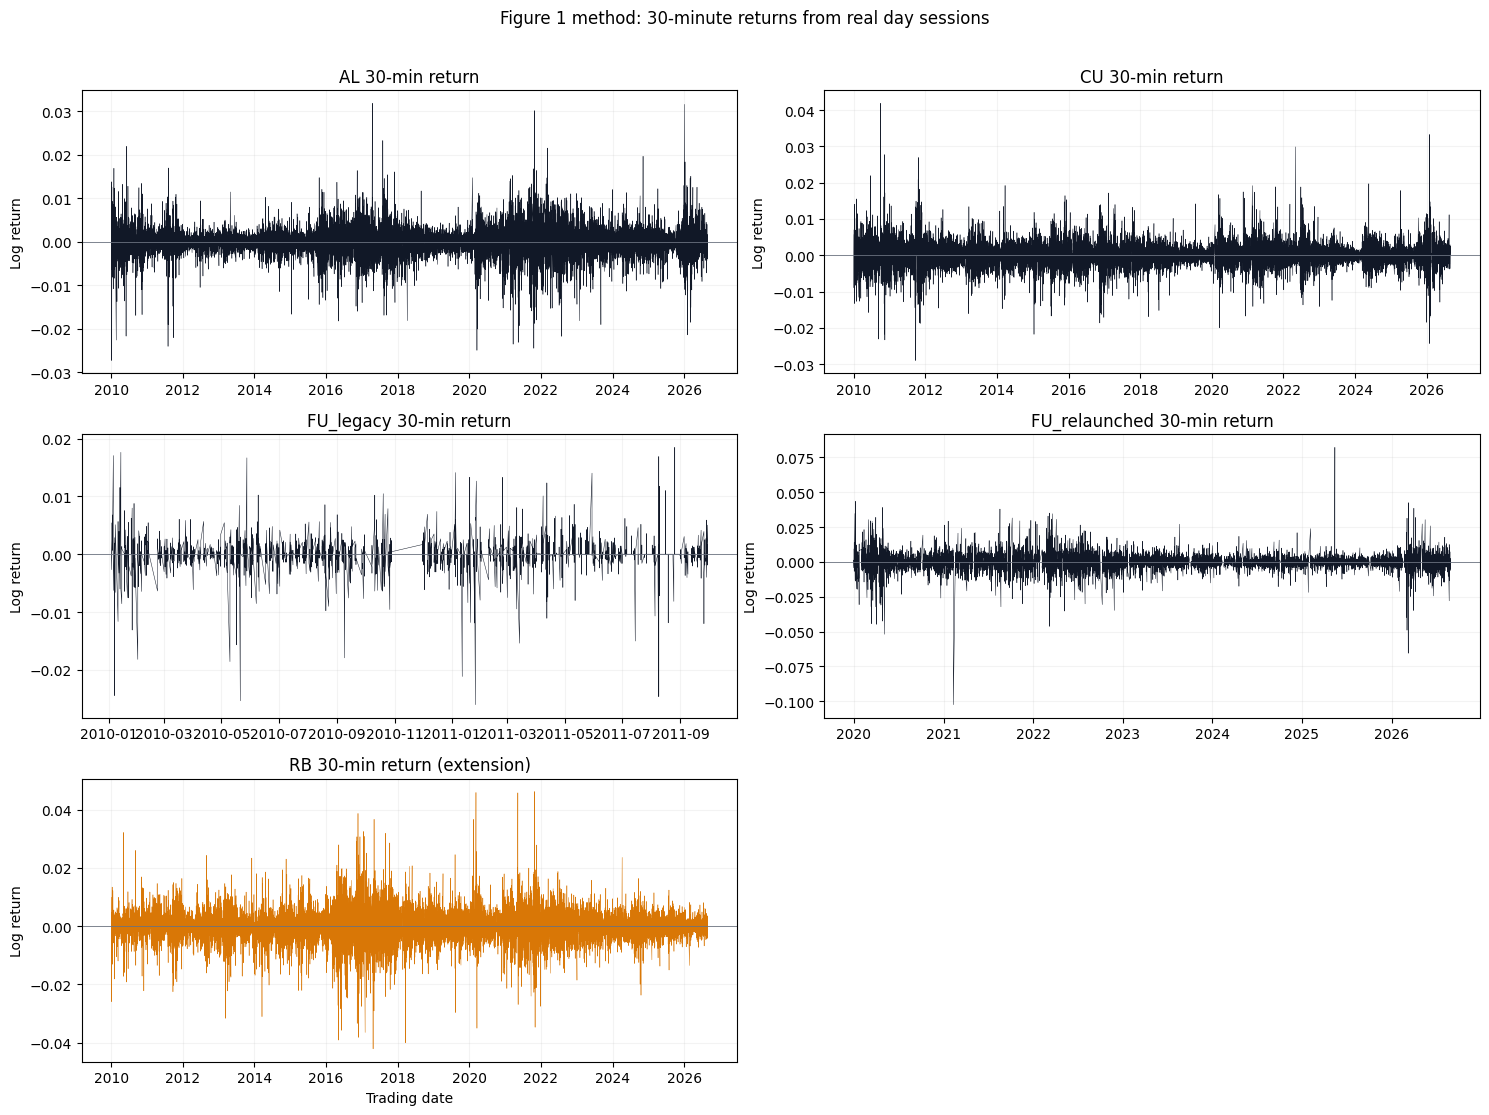

In [11]:
figure, axes = plt.subplots(3, 2, figsize=(15, 11), sharey=False)

for axis, series_id in zip(axes.flat, series_order):
    series_30_min_df = multiscale_return_df.loc[
        (multiscale_return_df["series_id"] == series_id)
        & (multiscale_return_df["interval_label"] == "30-min")
    ].sort_values(
        ["trading_date", "interval_slot"],
        ignore_index=True,
    )
    series_color = "#d97706" if series_id == "RB" else "#111827"
    axis.plot(
        series_30_min_df["trading_date"],
        series_30_min_df["interval_return"],
        color=series_color,
        linewidth=0.35,
    )
    axis.axhline(0.0, color="#6b7280", linewidth=0.6)
    axis.set_title(
        f"{series_id} 30-min return"
        + (" (extension)" if series_id == "RB" else "")
    )
    axis.set_ylabel("Log return")
    axis.grid(alpha=0.15)

axes.flat[-1].axis("off")
for axis in axes[-1, :]:
    axis.set_xlabel("Trading date")
figure.suptitle(
    "Figure 1 method: 30-minute returns from real day sessions",
    y=1.01,
)
figure.tight_layout()
plt.show()

In [12]:
frequency_comparison_df = (
    table3_style_df.pivot(
        index="Commodity",
        columns="Interval",
        values=["Stdev", "Kurt", "Zero return (%)"],
    )
)
display(frequency_comparison_df.round(4))

extreme_30_min_df = (
    multiscale_return_df.loc[
        multiscale_return_df["interval_label"] == "30-min",
        [
            "series_id",
            "contract_code",
            "trading_date",
            "interval_slot",
            "actual_interval_minutes",
            "interval_return",
            "is_roll_day",
        ],
    ]
    .assign(
        absolute_return=lambda frame: frame["interval_return"].abs()
    )
    .sort_values(
        ["series_id", "absolute_return"],
        ascending=[True, False],
    )
    .groupby("series_id", observed=True)
    .head(3)
    .sort_values(
        ["series_id", "absolute_return"],
        ascending=[True, False],
        ignore_index=True,
    )
)
display(extreme_30_min_df)

interpretation_lines = []
for series_id in series_order:
    series_stats_df = table3_style_df.loc[
        table3_style_df["Commodity"] == series_id
    ].set_index("Interval")
    zero_path = " → ".join(
        f"{interval_label} {series_stats_df.loc[interval_label, 'Zero return (%)']:.2f}%"
        for interval_label in interval_order
    )
    interpretation_lines.append(
        f"- **{series_id}** 零收益率：{zero_path}；"
        f"30 分钟超额峰度 {series_stats_df.loc['30-min', 'Kurt']:.2f}。"
    )

display(
    Markdown(
        f"""
### 样本内读数

{chr(10).join(interpretation_lines)}

这些统计量用于描述采样频率带来的信息—噪声权衡，不直接证明某个频率具有更好的预测能力；
预测优劣要留给后续固定样本外窗口、RMSFE 和统计检验。
"""
    )
)

Stdev                                      Kurt                                    Zero return (%)                                   
Interval        5-min  15-min  30-min  60-min   Daily     5-min   15-min   30-min   60-min   Daily           5-min   15-min   30-min   60-min   Daily
Commodity                                                                                                                                            
AL             0.0011  0.0018  0.0025  0.0035  0.0072   36.5072  16.6444  12.4696  11.4906  5.1964         22.4810  13.6943   8.7824   5.0742  0.8653
CU             0.0011  0.0018  0.0025  0.0036  0.0074   34.5021  18.9156  12.9091  10.2022  4.3209         11.6951   7.2386   4.6075   2.5216  0.1978
FU_legacy      0.0012  0.0020  0.0026  0.0036  0.0068  104.1460  44.2296  24.5910  12.8539  3.7245         44.6700  31.1386  23.8552  17.5743  6.9307
FU_relaunched  0.0022  0.0037  0.0051  0.0071  0.0134  143.5214  59.4926  31.2482  18.8647  6.3586         23.8786  14.7088   9.3789   5.2974  0.3717
RB             0.0017  0.0028  0.0038  0.0054  0.0109   55.2032  16.8809  11.7117   8.2439  4.2741         37.4262  23.1611  15.2689   8.3622  1.5575

,series_id,contract_code,trading_date,interval_slot,actual_interval_minutes,interval_return,is_roll_day,absolute_return
0,AL,AL1707.XSGE,2017-04-17,1,30,0.031868,False,0.031868
1,AL,AL2604.XSGE,2026-01-05,1,30,0.031613,True,0.031613
2,AL,AL2201.XSGE,2021-10-28,6,30,0.030153,False,0.030153
3,CU,CU1012.XSGE,2010-09-30,1,30,0.041883,False,0.041883
4,CU,CU2604.XSGE,2026-01-29,4,30,0.033277,False,0.033277
5,CU,CU2208.XSGE,2022-05-05,1,30,0.029861,True,0.029861
6,FU_legacy,FU1104.XSGE,2011-01-26,1,30,-0.026032,False,0.026032
7,FU_legacy,FU1008.XSGE,2010-05-21,1,30,-0.025363,False,0.025363
8,FU_legacy,FU1111.XSGE,2011-08-09,3,30,-0.024617,False,0.024617
9,FU_relaunched,FU2105.XSGE,2021-02-10,8,15,-0.102488,False,0.102488



### 样本内读数

- **AL** 零收益率：5-min 22.48% → 15-min 13.69% → 30-min 8.78% → 60-min 5.07% → Daily 0.87%；30 分钟超额峰度 12.47。
- **CU** 零收益率：5-min 11.70% → 15-min 7.24% → 30-min 4.61% → 60-min 2.52% → Daily 0.20%；30 分钟超额峰度 12.91。
- **FU_legacy** 零收益率：5-min 44.67% → 15-min 31.14% → 30-min 23.86% → 60-min 17.57% → Daily 6.93%；30 分钟超额峰度 24.59。
- **FU_relaunched** 零收益率：5-min 23.88% → 15-min 14.71% → 30-min 9.38% → 60-min 5.30% → Daily 0.37%；30 分钟超额峰度 31.25。
- **RB** 零收益率：5-min 37.43% → 15-min 23.16% → 30-min 15.27% → 60-min 8.36% → Daily 1.56%；30 分钟超额峰度 11.71。

这些统计量用于描述采样频率带来的信息—噪声权衡，不直接证明某个频率具有更好的预测能力；
预测优劣要留给后续固定样本外窗口、RMSFE 和统计检验。


## 10. 独立验证门禁

In [13]:
expected_bounds_df = (
    expected_sample_df.groupby("series_id", observed=True)["trading_date"]
    .agg(actual_start="min", actual_end="max")
    .reset_index()
    .merge(
        sample_spec_df[
            ["series_id", "sample_start", "sample_end"]
        ],
        on="series_id",
        validate="one_to_one",
    )
)
selected_day_count_by_series = (
    complete_contract_day_df.groupby("series_id", observed=True)
    ["is_complete_contract_day"]
    .sum()
    .to_dict()
)
expected_return_count_rows = []
for series_id, selected_day_count in selected_day_count_by_series.items():
    for interval_spec in interval_spec_df.itertuples(index=False):
        expected_return_count_rows.append(
            {
                "series_id": series_id,
                "interval_label": interval_spec.interval_label,
                "expected_return_count": (
                    int(selected_day_count)
                    * interval_spec.expected_daily_slots
                ),
            }
        )
expected_return_count_df = pd.DataFrame(expected_return_count_rows)
actual_return_count_df = (
    multiscale_return_df.groupby(
        ["series_id", "interval_label"],
        observed=True,
    )
    .size()
    .rename("actual_return_count")
    .reset_index()
)
return_count_audit_df = expected_return_count_df.merge(
    actual_return_count_df,
    on=["series_id", "interval_label"],
    validate="one_to_one",
)
return_count_audit_df["count_difference"] = (
    return_count_audit_df["actual_return_count"]
    - return_count_audit_df["expected_return_count"]
)

fu_legacy_last_date = multiscale_return_df.loc[
    multiscale_return_df["series_id"] == "FU_legacy",
    "trading_date",
].max()
fu_relaunched_first_date = multiscale_return_df.loc[
    multiscale_return_df["series_id"] == "FU_relaunched",
    "trading_date",
].min()
cross_frequency_maximum_difference = (
    daily_return_consistency_df[consistency_columns]
    .abs()
    .to_numpy()
    .max()
)

validation_gate_df = pd.DataFrame(
    [
        (
            "latitude_environment",
            current_python == expected_python,
            str(current_python),
        ),
        (
            "source_schema_physical_compatibility",
            source_contract_audit_df[
                "physical_mismatch_count"
            ].eq(0).all(),
            ", ".join(source_contract_audit_df["table_name"]),
        ),
        (
            "fixed_series_and_sample_endpoints",
            set(expected_sample_df["series_id"])
            == set(sample_spec_df["series_id"])
            and (
                expected_bounds_df["actual_start"]
                == expected_bounds_df["sample_start"]
            ).all()
            and (
                expected_bounds_df["actual_end"]
                == expected_bounds_df["sample_end"]
            ).all(),
            "五个序列均保持冻结起止日",
        ),
        (
            "unique_trade_month_plus_three_contract",
            contract_mapping_audit_df[
                "target_contract_count"
            ].isin([0, 1]).all()
            and contract_series_df["contract_code"].eq(
                contract_series_df["expected_contract_code"]
            ).all(),
            "每个可选交易日唯一，且合约代码 YYMM 与交易月后第 3 个月一致",
        ),
        (
            "known_fu1102_gap_only",
            actual_missing_keys_df.equals(known_missing_keys_df),
            (
                f"{len(actual_missing_keys_df)} 日，"
                "均为未上市的 FU1102.XSGE"
            ),
        ),
        (
            "day_sessions_only",
            not contract_calendar_df["is_night_session"].any()
            and not bar_calendar_df["is_night_session"].any(),
            "日历读取层排除夜盘；分钟事实通过精确日盘 Session 键内连接",
        ),
        (
            "upstream_bar_keys_complete",
            selected_bar_session_df["_merge"].eq("both").all()
            and complete_contract_day_df[
                "is_complete_contract_day"
            ].all(),
            (
                f"{len(complete_contract_day_df):,} 个合约日，"
                "均有 3 Session / 225 分钟正式完成证据"
            ),
        ),
        (
            "minute_rows_align_to_upstream_evidence",
            minute_read_audit_df[
                "session_alignment_failures"
            ].eq(0).all()
            and minute_read_audit_df[
                "selected_day_minute_rows"
            ].sum()
            == minute_read_audit_df[
                "expected_day_minute_rows"
            ].sum(),
            (
                f"{int(minute_read_audit_df['selected_day_minute_rows'].sum()):,}"
                " 个日盘分钟行"
            ),
        ),
        (
            "session_open_return_anchor",
            minute_read_audit_df["session_open_anchors"].sum()
            == len(complete_session_keys_df),
            "每个 Session 首分钟用本 Session 开盘价锚定，不跨休市",
        ),
        (
            "daily_slot_structure",
            slot_summary_df[
                [
                    "slot_count_failures",
                    "aggregated_minute_count_failures",
                    "non_last_slot_length_failures",
                    "last_slot_length_failures",
                ]
            ].eq(0).all().all(),
            "每日 45/15/8/4/1 槽；30/60 分钟末槽为 15/45 分钟",
        ),
        (
            "return_observation_counts",
            return_count_audit_df["count_difference"].eq(0).all(),
            (
                f"总收益观察 {len(multiscale_return_df):,}，"
                "逐序列逐频率与合约日 × 目标槽数一致"
            ),
        ),
        (
            "cross_frequency_daily_sum",
            cross_frequency_maximum_difference < 1e-12,
            (
                "5/15/30/60 分钟逐日加总均回到同一日收益；"
                f"最大绝对差 {cross_frequency_maximum_difference:.3e}"
            ),
        ),
        (
            "finite_returns_and_zero_bounds",
            np.isfinite(
                multiscale_return_df["interval_return"]
            ).all()
            and table3_style_df[
                "Zero return (%)"
            ].between(0, 100).all(),
            "全部收益有限；零收益百分比位于 0—100",
        ),
        (
            "fu_segments_are_independent",
            fu_legacy_last_date < fu_relaunched_first_date,
            (
                f"legacy_end={fu_legacy_last_date.date()}, "
                f"relaunched_start={fu_relaunched_first_date.date()}"
            ),
        ),
        (
            "rb_extension_is_separate",
            sample_spec_df.loc[
                sample_spec_df["series_id"] == "RB",
                "research_role",
            ].eq("论文外扩展品种").all()
            and "RB" in table3_style_df["Commodity"].astype("string").unique(),
            "RB 单列，不并入论文品种标签",
        ),
    ],
    columns=["gate", "passed", "evidence"],
)
display(return_count_audit_df)
display(validation_gate_df)
assert validation_gate_df["passed"].all(), validation_gate_df.loc[
    ~validation_gate_df["passed"]
]

,series_id,interval_label,expected_return_count,actual_return_count,count_difference
0,AL,5-min,182025,182025,0
1,AL,15-min,60675,60675,0
2,AL,30-min,32360,32360,0
3,AL,60-min,16180,16180,0
4,AL,Daily,4045,4045,0
5,CU,5-min,182025,182025,0
6,CU,15-min,60675,60675,0
7,CU,30-min,32360,32360,0
8,CU,60-min,16180,16180,0
9,CU,Daily,4045,4045,0


,gate,passed,evidence
0,latitude_environment,True,E:\anaconda3\envs\latitude\python.exe
1,source_schema_physical_compatibility,True,"dim_futures_variety_calendar, dim_futures_contract_calendar, dim_futures_bar_calendar, fact_futures_minute"
2,fixed_series_and_sample_endpoints,True,五个序列均保持冻结起止日
3,unique_trade_month_plus_three_contract,True,每个可选交易日唯一，且合约代码 YYMM 与交易月后第 3 个月一致
4,known_fu1102_gap_only,True,22 日，均为未上市的 FU1102.XSGE
5,day_sessions_only,True,日历读取层排除夜盘；分钟事实通过精确日盘 Session 键内连接
6,upstream_bar_keys_complete,True,"14,153 个合约日，均有 3 Session / 225 分钟正式完成证据"
7,minute_rows_align_to_upstream_evidence,True,"3,184,425 个日盘分钟行"
8,session_open_return_anchor,True,每个 Session 首分钟用本 Session 开盘价锚定，不跨休市
9,daily_slot_structure,True,每日 45/15/8/4/1 槽；30/60 分钟末槽为 15/45 分钟


## 11. 结果解释边界与限制

1. 本项复现的是论文 Table 3 与 Figure 1 的统计方法，不是 GTA 原数值。样本、数据源、交易制度和真实日盘长度均不同。
2. 日收益只包含三个真实日盘 Session 内的价格变化；它刻意排除夜盘、隔夜、晨休、午休和换月跨日跳空，不能解释为完整持有期收益。
3. 30、60 分钟槽位按真实交易分钟序列切分，部分槽位会跨 Session 组合两段收益，但不包含两段之间的价格跳变；末槽时长差异会在后续季节因子中单独吸收。
4. 换月日直接使用当日新固定月份合约的 Session 内收益，不做论文未披露的复权，也不连接上一交易日旧合约价格。
5. 零收益阈值仅用于 Table 3 的计数，不修改任何原始或聚合收益值。
6. Figure 1 风格图保留全部 30 分钟观察；FU 两段不跨停牌期连接，RB 使用单独颜色和扩展标签。
7. 后续 Notebook 必须继续在自身重算所需收益，不读取本 Notebook 的内存对象或持久化中间产物。